Dataset Shape: (1797, 64)
Target Classes: [0 1 2 3 4 5 6 7 8 9]


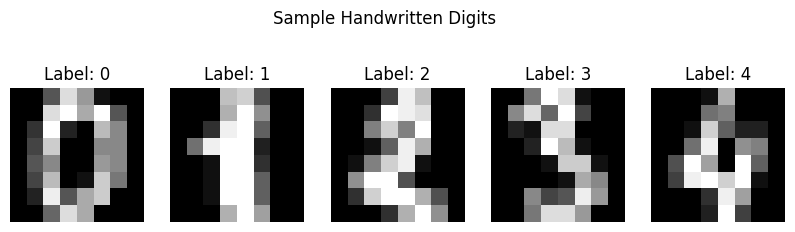


--- TUNING K VALUE ---
K=3: Accuracy = 0.9694
K=5: Accuracy = 0.9750
K=7: Accuracy = 0.9722
K=9: Accuracy = 0.9722


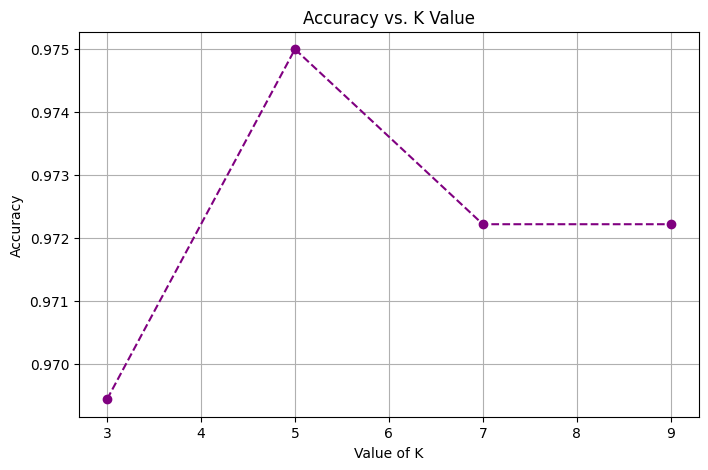


--- FINAL MODEL (K=3) ---
Accuracy: 0.9694

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      1.00      0.97        28
           2       0.94      0.97      0.96        33
           3       0.97      0.97      0.97        34
           4       0.98      1.00      0.99        46
           5       0.98      0.96      0.97        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       0.97      0.93      0.95        30
           9       0.95      0.90      0.92        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



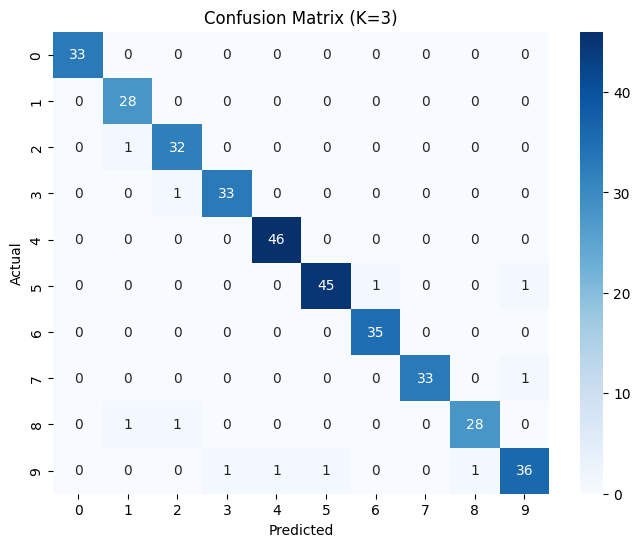

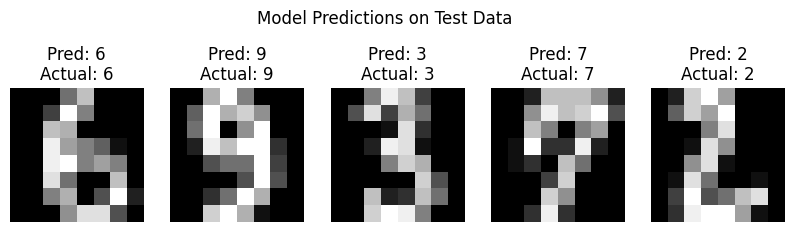

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load Dataset
# The digits dataset consists of 8x8 pixel images of digits 0-9
digits = load_digits()

X = digits.data   # Features (pixel intensities)
y = digits.target # Labels (0-9)

print(f"Dataset Shape: {X.shape}")
print(f"Target Classes: {np.unique(y)}")

# 2. Visualize Digits
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.suptitle("Sample Handwritten Digits")
plt.show()

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling
# KNN relies on distance, so scaling is CRITICAL
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Find Best K (Hyperparameter Tuning)
k_values = [3, 5, 7, 9]
accuracies = []

print("\n--- TUNING K VALUE ---")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    score = knn.score(X_test, y_test)
    accuracies.append(score)
    print(f"K={k}: Accuracy = {score:.4f}")

# Plot Accuracy vs K
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='--', color='purple')
plt.xlabel("Value of K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. K Value")
plt.grid(True)
plt.show()

# 6. Train Final Model (Using Best K, usually 3 or 5)
best_k = 3
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)

# 7. Evaluation
y_pred = model.predict(X_test)

print(f"\n--- FINAL MODEL (K={best_k}) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix (K={best_k})")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 8. Visualizing Predictions
# Let's show a few test images and what the model predicted
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
X_test_original = scaler.inverse_transform(X_test) # Undo scaling to view image

for i, ax in enumerate(axes):
    # Reshape the flattened array back to 8x8 image
    img = X_test_original[i].reshape(8, 8)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Pred: {y_pred[i]}\nActual: {y_test[i]}")
    ax.axis('off')
plt.suptitle("Model Predictions on Test Data")
plt.show()